In [42]:
import pandas as pd
import numpy as np
import os
import yaml
import json

# Load config
#config_path = "/app/bindmount/gedi_data_2/config.yaml"
#config_path = "/app/bindmount/gedi_data_real_scan/config_real_scan.yaml"
#config_path = "/app/bindmount/gedi_data_real_scan_5x315/config_real_scan_5x315.yaml"
config_path = "/app/bindmount/gedi_data_4meters_scans/config_4meters.yaml"
with open(config_path, "r") as file:
        config = yaml.safe_load(file)

base = config["base"]
coarse_score_df = config["paths"]["results"]["filtering_fine"]
file_name = config["paths"]["results"]["filtering_fine_file_name"]
path = os.path.join(base, coarse_score_df, file_name)
fine_score_df = pd.read_json(path)
fine_score_df = fine_score_df.T
fine_score_df

""


In [36]:
import pandas as pd

def sort_by_ransac_fitness(scan_data):
    """
    Sort the scan data by ransac_fitness in descending order.
    """
    return scan_data.sort_values(
        key=lambda s: s.apply(lambda res: res["ransac_fitness"]),
        ascending=False
    )
    
def sort_by_ransac_inlier_rmse(scan_data):
    """
    Sort the scan data by ransac_inlier_rmse in descending order.
    """
    return scan_data.sort_values(
        key=lambda s: s.apply(lambda res: res["ransac_inlier_rmse"]),
        ascending=True
    )
    
def sort_by_fitness_and_rmse(scan_data_series):
    """
    Sorts the series first by ransac_fitness (descending order) then by ransac_inlier_rmse (ascending order).
    To achieve descending order for fitness, we use -fitness.
    """
    def sort_key(res):
        # Multiply fitness by -1 so that higher fitness sorts first;
        # rmse is kept as is so lower rmse sorts before higher rmse.
        return (-res["ransac_fitness"], res["ransac_inlier_rmse"])
    
    sorted_series = scan_data_series.sort_values(
        key=lambda s: s.apply(sort_key)
    )
    return sorted_series
    

In [38]:
# Prepare an empty dictionary to collect rank info
rank_data = {"scan": [], "rank_fitness": [], "rank_rmse": [], "rank_fitness_rmse": []}

# Iterate over each scan (each index in fine_score_df)
for scan in fine_score_df.index:
    scan_data = fine_score_df.loc[scan]
    # Drop any NaN entries
    scan_data_clean = scan_data.dropna()
    rank_data["scan"].append(scan)
    
    # --- Sort by ransac_fitness ---
    sorted_scan_fitness = sort_by_ransac_fitness(scan_data_clean)
    try:
        rank_fitness = sorted_scan_fitness.index.get_loc(scan) + 1  # get_loc returns zero-based position
    except KeyError:
        rank_fitness = None
    rank_data["rank_fitness"].append(rank_fitness)
    
    # --- Sort by ransac_inlier_rmse ---
    sorted_scan_rmse = sort_by_ransac_inlier_rmse(scan_data_clean)
    try:
        rank_rmse = sorted_scan_rmse.index.get_loc(scan) + 1
    except KeyError:
        rank_rmse = None
    rank_data["rank_rmse"].append(rank_rmse)
    
    # --- Sort by both ransac_fitness and ransac_inlier_rmse ---
    sorted_scan_fitness_rmse = sort_by_fitness_and_rmse(scan_data_clean)
    try:
        rank_fitness_rmse = sorted_scan_fitness_rmse.index.get_loc(scan) + 1
    except KeyError:
        rank_fitness_rmse = None
    rank_data["rank_fitness_rmse"].append(rank_fitness_rmse)

     scan  rank_fitness  rank_rmse  rank_fitness_rmse
0       1           1.0        1.0                1.0
1  778817          25.0       14.0               25.0
2  779632           1.0       13.0                1.0
3  785583           1.0       23.0                1.0
4  793998           NaN        NaN                NaN


/tmp/ipykernel_2037/3117455141.py:9: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-whitegrid")


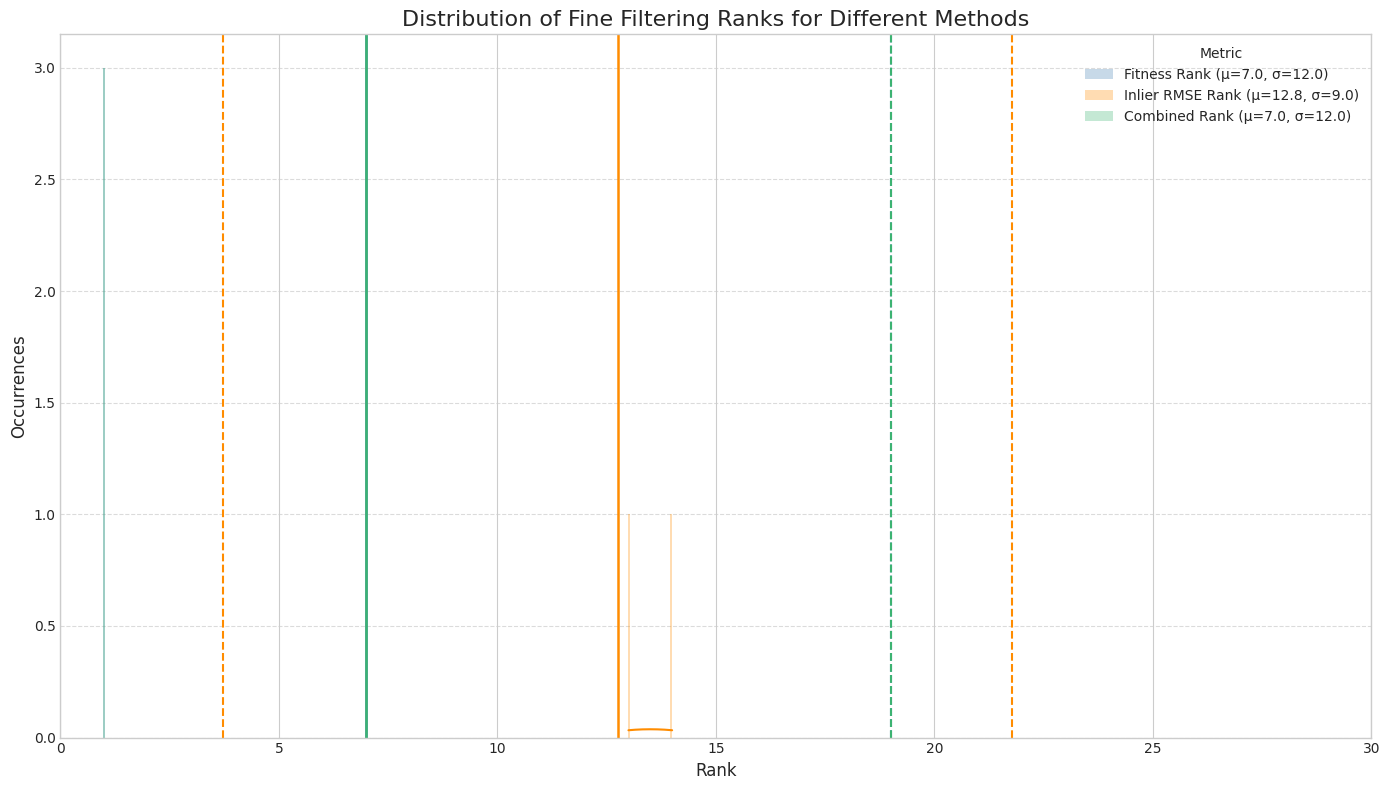

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert rank_data to a DataFrame for further processing
fine_rank_df = pd.DataFrame(rank_data)
print(fine_rank_df)

# ----- Plotting the Rank Distributions ----- #
plt.style.use("seaborn-whitegrid")
plt.figure(figsize=(14, 8))

# Define the metrics for plotting: column name in fine_rank_df, display title, and color
plot_metrics = [
    ("rank_fitness", "Fitness Rank", "steelblue"),
    ("rank_rmse", "Inlier RMSE Rank", "darkorange"),
    ("rank_fitness_rmse", "Combined Rank", "mediumseagreen")
]

# Loop over each metric to plot its distribution
for metric, title, color in plot_metrics:
    data = fine_rank_df[metric].dropna()  # drop None values that might appear if a scan was not found
    m = data.mean()
    s = data.std()
    # Optionally, filter data to [mean - std, mean + std] to focus on the main cluster
    filtered = data[(data >= m - s) & (data <= m + s)]
    
    sns.histplot(filtered, bins=25, kde=True, stat="count",
                 label=f"{title} (μ={m:.1f}, σ={s:.1f})",
                 color=color, fill=True, alpha=0.3, linewidth=0)
    
    # Add vertical lines for the mean and ± standard deviation
    plt.axvline(m, color=color, linestyle='-', linewidth=1.8)
    plt.axvline(m - s, color=color, linestyle='--', linewidth=1.5)
    plt.axvline(m + s, color=color, linestyle='--', linewidth=1.5)

# Final plot styling
plt.title("Distribution of Fine Filtering Ranks for Different Methods", fontsize=16)
plt.xlabel("Rank", fontsize=12)
plt.ylabel("Occurrences", fontsize=12)
plt.xlim(0, 30)  # adjust these limits based on your data
plt.legend(title="Metric", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()